# M3 — Linear attention *is* fast weights

**The question:** what happens to attention if you delete the softmax?

Third module of the foundations spine. Runs on CPU in seconds; PyTorch throughout. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m3-linear-attention.ipynb)

M2 built a fast-weight programmer **from the Schmidhuber side**: a slow net writes an outer-product memory $\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top$. M3 reaches the **same object from the Transformer side** — take ordinary attention, delete the softmax, and the whole "attend to every past token" sum **collapses into exactly that matrix**. So a *linear* Transformer is secretly an RNN with a matrix memory, and that memory is M2's fast weights.

> **Prerequisite math** — *effective rank / capacity* and *orthogonality* (what the feature map $\phi$ buys) are in the [linear-algebra primer](../primers/linear-algebra.ipynb) §1, §3.

## Objective

After this module you should be able to:

- Rebuild **softmax self-attention** from query/key/value and read it as content-addressable lookup — and see *why* softmax makes recall sharp but costs $O(N^2)$ and a growing KV cache.
- Write attention as a **kernel** $\mathrm{sim}(\mathbf{q},\mathbf{k})$ and see that softmax is the *one specific kernel* ($\exp$) that **forbids** factorization — which is why real attention must keep every token.
- Replace the kernel with a **factorizable** feature map $\mathrm{sim}(\mathbf{q},\mathbf{k})=\phi(\mathbf{q})^\top\phi(\mathbf{k})$ and use **associativity** to collapse the $O(N^2)$ token-by-token sum into a single fixed-size matrix $\mathbf{S}=\sum_j\phi(\mathbf{k}_j)\mathbf{v}_j^\top$.
- Recognize that $\mathbf{S}$ **is M2's fast-weight memory** $\mathcal{M}$ — same outer-product write — so *linear attention = fast-weight programmer = a linear RNN*. Three names, one recurrence.
- Switch between the **parallel form** (train like a Transformer, $O(N^2)$) and the **recurrent form** (infer like an RNN, $O(1)$ per token) and verify they compute the identical function.
- Explain where the feature map $\phi$ buys back the capacity from M2's capacity law, and what it costs.

## Why it exists (the limitation it fixes)

M2 left us with a working fast-weight layer and no reason to trust it. It was an orphan mechanism: an outer-product memory that Schmidhuber proposed in 1992, justified on its own terms, with no stated relationship to the architecture that actually went on to win everything. Nothing in M2 tells you whether the fast-weight write is a curiosity or a necessity — and that open question from M1's §4 callout is still sitting there: *what exactly makes something "linear attention," and how does it relate to the Transformer you already know?*

M3 repairs that by deriving M2's memory from the Transformer instead of postulating it. Take softmax self-attention ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)), remove exactly one operation, and M2's write is what falls out — not an alternative to attention but what attention *is* once you stop paying for the softmax. The orphan gets a parent.

The operation is worth removing on its own merits. Softmax attention computes a similarity between **every pair** of positions: an $N\times N$ matrix for a length-$N$ sequence. That is $O(N^2)$ time and memory, and autoregressive decoding makes it worse — each new token attends to **all** previous tokens, so you cache every past key and value (the KV cache grows without bound). This is *the* scaling wall of Transformers.

The fix is almost embarrassingly simple: **remove the softmax.** Once the pairwise similarity factorizes, the sum over past tokens re-associates into a running matrix you can carry forward — constant memory, linear time. And that running matrix is precisely the fast-weight memory M2 already built.

Two groups walked into this from opposite doors, which is why the identity is worth a module of its own. [Katharopoulos et al. (2020)](https://arxiv.org/abs/2006.16236) came from the efficiency side — they wanted attention to stop costing $O(N^2)$, found the collapse, and noticed the result was an RNN; they say nothing about fast weights. A year later, [Schlag, Irie & Schmidhuber (2021)](https://arxiv.org/abs/2102.11174) came from Schmidhuber's own side and proved the two are formally the same object — the "secretly" in their title is doing real work, reporting a connection that the efficiency line had not seen. M3 is where the two lineages turn out to be one thing.

## Core idea — take attention apart, then put it back cheap

The whole module is one move: write attention with a **general** similarity kernel, notice that **softmax is the single kernel that blocks factorization**, and swap it for a factorizable feature map $\phi$. The instant you do, the "attend to every past token" sum re-associates into one fixed-size matrix — and that matrix is M2's fast-weight memory.

So we go in order, building the thing before we break it:

1. **§1–§2** — rebuild **original (softmax) attention** from query/key/value and feel its cost.
2. **§3 onward** — delete the softmax and watch **linear attention / fast weights** fall out, then the parallel↔recurrent duality and the price of going linear.

### Reading

- [Linear Transformers](https://arxiv.org/abs/2006.16236) (*Transformers are RNNs*) — §3.2 (Linearized Attention: the kernel factorization), §3.2.1 (the feature map $\phi=\mathrm{elu}+1$, Eq. 7), §3.4 (Transformers are RNNs: the recurrence $s_i=s_{i-1}+\phi(x_iW_K)(x_iW_V)^\top$, Eq. 18). The grounding source.
- [FWP](https://arxiv.org/abs/2102.11174) §3.1–§3.2 — the same identity reached from the fast-weights side — and §4.1, the capacity analysis we tie back to.
- [Transformer Dissection](https://arxiv.org/abs/1908.11775) (Tsai et al., 2019) §3 — where §3's general-kernel formulation comes from, one step upstream of the linearization.

## 1. Attention, from scratch — query, key, value

One self-attention layer — the scaled dot-product attention of [Vaswani et al. (2017)](https://arxiv.org/abs/1706.03762) — turns each token $\mathbf{x}_t$ into three roles via learned projections:

- **query** $\mathbf{q}_t = W_Q\mathbf{x}_t$ — what position $t$ is looking for,
- **key** $\mathbf{k}_t = W_K\mathbf{x}_t$ — the handle position $t$ advertises to others,
- **value** $\mathbf{v}_t = W_V\mathbf{x}_t$ — the content it contributes if attended to.

$W_Q,W_K,W_V$ are trained once and **frozen at inference** — they are exactly M2's *slow weights*, the fixed program. Every query is scored against every key with a scaled dot product, the scores are turned into weights by a **softmax**, and the values are read out in those proportions. Stacked over all positions, that is the layer as it is usually written:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V.$$

Take one query out of the stack and write the softmax out — exponentiate each score, divide by their total — and the same layer reads:

$$\mathbf{o}_t=\frac{\displaystyle\sum_{j\le t}\exp\big(\mathbf{q}_t^\top\mathbf{k}_j/\sqrt{d}\big)\,\mathbf{v}_j}{\displaystyle\sum_{j\le t}\exp\big(\mathbf{q}_t^\top\mathbf{k}_j/\sqrt{d}\big)}.$$

Exponentiated scores on top, their total — the normalizer $Z_t$, one scalar per query — underneath. ($j\le t$ enforces causality: position $t$ sees only the past.)

Read it as **content-addressable, soft dictionary lookup**: the query retrieves a blend of the values whose keys it matches. Softmax makes it a *competition* — the best-matching key dominates, the rest are suppressed. That sharp, winner-take-most selection is exactly what makes softmax attention so good at *exact recall* — and the property we sacrifice when we linearize.

Keep this shape in mind. §3 changes exactly one symbol in it.

The cell builds this from a raw input $X$, one step at a time, then checks the intuition: a query deliberately aligned with one key should pull out that key's value almost alone.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)

N, d_model, d, m = 12, 16, 8, 8
X = torch.randn(N, d_model)                       # a sequence of N tokens

W_Q = nn.Linear(d_model, d, bias=False)           # SLOW weights -- M2's fixed program
W_K = nn.Linear(d_model, d, bias=False)
W_V = nn.Linear(d_model, m, bias=False)
Q, K, V = W_Q(X), W_K(X), W_V(X)                  # project each token into its three roles

def softmax_attention(Q, K, V, causal=True):
    N, d = Q.shape
    scores = (Q @ K.t()) / d**0.5                 # (N, N) pairwise similarities
    if causal:
        mask = torch.triu(torch.ones(N, N, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float('-inf'))
    A = scores.softmax(dim=-1)                     # row-normalized weights (each row sums to 1)
    return A @ V, A                               # weighted average of values

O, A = softmax_attention(Q, K, V)
print("X:", tuple(X.shape), "-> Q,K,V:", tuple(Q.shape), tuple(K.shape), tuple(V.shape))
print("attention weights A:", tuple(A.shape), " rows sum to 1:",
      torch.allclose(A.sum(-1), torch.ones(N)))
print("output O:", tuple(O.shape))

# Intuition: a query pointed straight at key 5 should retrieve mostly value 5 (non-causal probe).
q = K[5:6] * 6.0
w = ((q @ K.t()) / d**0.5).softmax(-1)
rel = ((w @ V) - V[5:6]).norm() / V[5:6].norm()
print(f"\nquery aligned with key 5 -> weight on token 5 = {w[0,5]:.2f}  (uniform would be {1/N:.2f})")
print(f"retrieval error vs value[5] = {rel:.2f}  -> softmax concentrates on the matching key")

X: (12, 16) -> Q,K,V: (12, 8) (12, 8) (12, 8)
attention weights A: (12, 12)  rows sum to 1: True
output O: (12, 8)

query aligned with key 5 -> weight on token 5 = 0.81  (uniform would be 0.08)
retrieval error vs value[5] = 0.13  -> softmax concentrates on the matching key


## 2. Why attention is expensive — it keeps every token

The scores $A$ form an $N\times N$ matrix: **every** query against **every** key. That is the cost.

- **Compute/memory:** building and storing $A$ is $O(N^2)$ — quadratic in sequence length.
- **Inference:** to score the next token you need all past keys and values, so you cache them — the **KV cache grows linearly with $N$**, unbounded.

The cell visualizes the object we are paying for: a dense, causal $N\times N$ triangle. Everything in M3 is about replacing it with something fixed-size.

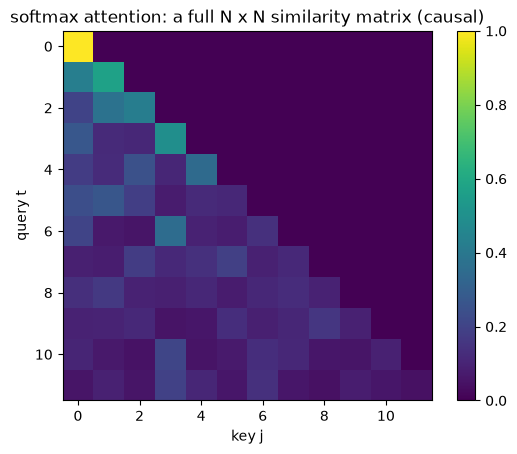

A is N x N = (12, 12) and grows with N; at inference you cache every past K, V.
=> O(N^2) time and memory. That is the wall linear attention removes.


In [2]:
O, A = softmax_attention(Q, K, V)
plt.imshow(A.detach(), cmap="viridis"); plt.colorbar()
plt.title("softmax attention: a full N x N similarity matrix (causal)")
plt.xlabel("key j"); plt.ylabel("query t"); plt.show()
print("A is N x N =", tuple(A.shape), "and grows with N; at inference you cache every past K, V.")
print("=> O(N^2) time and memory. That is the wall linear attention removes.")

## 3. Delete the softmax — associativity collapses the sum

Write attention with a **general** similarity kernel instead of the specific softmax one:

$$\mathbf{o}_t = \frac{\sum_{j\le t}\mathrm{sim}(\mathbf{q}_t,\mathbf{k}_j)\,\mathbf{v}_j}{\sum_{j\le t}\mathrm{sim}(\mathbf{q}_t,\mathbf{k}_j)}.$$

Reading attention this way — as a kernel applied to pairs of inputs, with softmax just one choice of kernel — is [Tsai et al.'s (2019)](https://arxiv.org/abs/1908.11775) reframing, and it is the step that makes everything after it possible: once $\exp$ is a *parameter* rather than part of the definition, you can ask what other kernels are legal. Katharopoulos et al. build directly on it.

Softmax is the choice $\mathrm{sim}(\mathbf{q},\mathbf{k})=\exp(\mathbf{q}^\top\mathbf{k}/\sqrt d)$. The exponential of a dot product **does not split** into a $\mathbf{q}$-part times a $\mathbf{k}$-part — so you are stuck with all $N^2$ similarities and must keep every token (that was §2).

Now demand a kernel that **does** split: a feature map $\phi$ with $\mathrm{sim}(\mathbf{q},\mathbf{k})=\phi(\mathbf{q})^\top\phi(\mathbf{k})$. This is [Katharopoulos et al.'s (2020)](https://arxiv.org/abs/2006.16236) move, §3.2 — take the kernel view and impose factorization on it. Substitute and pull $\phi(\mathbf{q}_t)$ out of the sum (associativity of the matrix product):

$$\mathbf{o}_t = \frac{\big(\sum_{j\le t}\mathbf{v}_j\,\phi(\mathbf{k}_j)^\top\big)\,\phi(\mathbf{q}_t)}{\big(\sum_{j\le t}\phi(\mathbf{k}_j)^\top\big)\,\phi(\mathbf{q}_t)} = \frac{\mathbf{S}_t\,\phi(\mathbf{q}_t)}{\mathbf{z}_t^\top\phi(\mathbf{q}_t)},\qquad \mathbf{S}_t=\sum_{j\le t}\mathbf{v}_j\phi(\mathbf{k}_j)^\top,\;\; \mathbf{z}_t=\sum_{j\le t}\phi(\mathbf{k}_j).$$

The "sum over all past tokens" has **collapsed into one fixed-size matrix** $\mathbf{S}_t$ (plus a normalizer $\mathbf{z}_t$). You no longer store tokens — you store their accumulated outer products. Incrementally:

$$\boxed{\;\mathbf{S}_t = \mathbf{S}_{t-1} + \mathbf{v}_t\,\phi(\mathbf{k}_t)^\top, \qquad \mathbf{o}_t \propto \mathbf{S}_t\,\phi(\mathbf{q}_t)\;}$$

— which is **M2's fast-weight write**, the only change being that the raw key passes through $\phi$ first.

The cell makes the collapse concrete. With $\mathrm{sim}=\phi(\mathbf{q})^\top\phi(\mathbf{k})$ the **same numbers** group two ways: $(\Phi_Q\Phi_K^\top)\,V$ builds the $N\times N$ scores first (quadratic), while $\Phi_Q\,(\Phi_K^\top V)$ builds the small $\mathbf{S}=\Phi_K^\top V$ first (linear). For *non-causal* attention they are algebraically identical — same result, and $\mathbf{S}$ is fixed-size regardless of $N$.

In [3]:
def phi(x):
    # feature map: elu(x)+1  -> strictly positive, so similarities stay non-negative
    return F.elu(x) + 1.0

def linear_attn_two_ways(Q, K, V):
    PQ, PK = phi(Q), phi(K)                       # (N, p)
    # (a) attention grouping: build the N x N score matrix, then mix values
    O_quad = (PQ @ PK.t()) @ V                    # (N,N) intermediate
    # (b) fast-weight grouping: build S = sum_j phi(k_j) v_j^T first, then read
    S = PK.t() @ V                                # (p, m)  <-- fixed size, independent of N
    O_lin = PQ @ S
    return O_quad, O_lin, S

O_quad, O_lin, S = linear_attn_two_ways(Q, K, V)
print("same function, two groupings -> identical:", torch.allclose(O_quad, O_lin, atol=1e-5))
print("attention grouping forms an N x N =", (N, N), "matrix")
print("fast-weight grouping forms S =", tuple(S.shape), "(p x m) -- size does NOT grow with N")

same function, two groupings -> identical: True
attention grouping forms an N x N = (12, 12) matrix
fast-weight grouping forms S = (8, 8) (p x m) -- size does NOT grow with N


::: {.callout-note collapse="true"}
## Q: Does softmax forbid the collapse *because* it's a sharp, winner-take-most competition?

Half right — and the half that's off is worth pulling apart, because softmax has **two separate properties** and only one of them is the obstruction.

- **Sharp competition (winner-take-most)** — real, and it's why softmax recalls *exactly*: the normalized exponential piles weight onto the best-matching key. This is the property §6's probe shows linear attention losing (the `dd=64` cell in §6 drives it home: softmax error → **0.000**, exact recall).
- **Non-factorizability** — *this* is what blocks the collapse. The sum collapses (§3) only if the score splits as $\mathrm{sim}(\mathbf{q},\mathbf{k})=\phi(\mathbf{q})^\top\phi(\mathbf{k})$ — a $\mathbf{q}$-part times a $\mathbf{k}$-part — so you can pull $\phi(\mathbf{q}_t)$ out of the sum. The softmax score $\exp(\mathbf{q}^\top\mathbf{k}/\sqrt d)$ **does not split**. That's a purely *algebraic* fact about the exponential of a dot product; it has nothing to do with how peaked the weights are.

**The clean test that separates them:** crank the softmax **temperature**. $\exp(\mathbf{q}^\top\mathbf{k}/\tau)$ with large $\tau$ gives a nearly *uniform* distribution — no winner at all — yet it *still* cannot be collapsed to a finite-size state. Sharpness changed; collapsibility didn't. So sharpness is not the cause.

**But the instinct isn't wrong — the two share a root.** The exponential kernel corresponds to an **infinite-dimensional** feature map: $\exp(\mathbf{q}^\top\mathbf{k})=\sum_{n\ge 0}\frac{(\mathbf{q}^\top\mathbf{k})^n}{n!}$ — polynomial features of *every* degree. That single fact does both jobs at once:

- infinite dimension is *why* it can't be written as a finite $\phi(\mathbf{q})^\top\phi(\mathbf{k})$ → **no finite-state collapse**, and
- infinite dimension is *why* it can carve out one key arbitrarily sharply → **exact recall**.

A finite feature map $\phi:\mathbb{R}^d\to\mathbb{R}^p$ is a *finite-rank approximation* of that kernel: it **buys** the $O(N)$ collapse and **pays** in sharpness — only $\sim p$ associations fit before outer products superpose and interfere (§6's lossy recall; M2's capacity law). So the right mental model is: **sharpness and non-collapsibility are siblings — both children of the infinite-dimensional exp kernel — not cause and effect.** Linearizing trades the infinite dimension (sharp, uncollapsible) for a finite one (blurrier, collapsible).
:::

## 4. That matrix $\mathbf{S}$ is M2's fast-weight memory

Look again at $\mathbf{S}=\sum_j\mathbf{v}_j\phi(\mathbf{k}_j)^\top$ — a sum of outer products of values and (feature-mapped) keys. That is **exactly** M2's write $\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top$, with $\mathbf{k}\mapsto\phi(\mathbf{k})$. The "linear Transformer" and the "fast-weight programmer" are the *same object*; M2 reached it by asking how to write a memory, M3 by asking how to make attention cheap.

The cell rebuilds the **causal** linear attention as M2's per-token loop — initialize $\mathbf{S}=0$, write one outer product per token, read with the query — and confirms it matches the masked parallel form. This loop is identical in shape to M2's `FWPLayer.forward`; the only new ingredient is $\phi$.

In [4]:
def linear_attn_recurrent(Q, K, V):
    # M2's fast-weight loop, with phi on the keys/queries. Causal by construction.
    PQ, PK = phi(Q), phi(K)
    p, mdim = PK.shape[1], V.shape[1]
    S = torch.zeros(mdim, p)                 # fast-weight memory M, fresh per sequence
    z = torch.zeros(p)                       # running key-sum for the normalizer
    outs = []
    for t in range(Q.shape[0]):
        S = S + torch.outer(V[t], PK[t])     # WRITE: one outer product (M2's update, k -> phi(k))
        z = z + PK[t]
        num = S @ PQ[t]                      # READ:  query the memory
        outs.append(num / (z @ PQ[t] + 1e-6))
    return torch.stack(outs)

def linear_attn_parallel_causal(Q, K, V):
    # same thing as one masked matmul (the training-time form)
    PQ, PK = phi(Q), phi(K)
    scores = PQ @ PK.t()                                  # (N, N), unnormalized
    mask = torch.tril(torch.ones(N, N))
    scores = scores * mask
    num = scores @ V
    den = (scores.sum(dim=-1, keepdim=True)) + 1e-6
    return num / den

O_rec = linear_attn_recurrent(Q, K, V)
O_par = linear_attn_parallel_causal(Q, K, V)
print("recurrent fast-weight loop == parallel masked form:",
      torch.allclose(O_rec, O_par, atol=1e-5))
print("the per-token loop IS M2's FWPLayer.forward, with k -> phi(k). Same recurrence, new name.")

recurrent fast-weight loop == parallel masked form: True
the per-token loop IS M2's FWPLayer.forward, with k -> phi(k). Same recurrence, new name.


::: {.callout-note collapse="true"}
## Q: Write the boxed recurrence from memory, and point to exactly where it is M2's fast-weight write.

$$\boxed{\;\mathbf{S}_t=\mathbf{S}_{t-1}+\mathbf{v}_t\,\phi(\mathbf{k}_t)^\top,\qquad \mathbf{o}_t\propto \mathbf{S}_t\,\phi(\mathbf{q}_t)\;}\qquad\Big(\text{normalizer }\mathbf{z}_t=\mathbf{z}_{t-1}+\phi(\mathbf{k}_t),\ \ \mathbf{o}_t=\tfrac{\mathbf{S}_t\phi(\mathbf{q}_t)}{\mathbf{z}_t^\top\phi(\mathbf{q}_t)}\Big)$$

Term by term: each token adds one **outer product** $\mathbf{v}_t\phi(\mathbf{k}_t)^\top$ into the matrix $\mathbf{S}_t\in\mathbb{R}^{m\times p}$ — store the association "key $\phi(\mathbf{k}_t)\Rightarrow$ value $\mathbf{v}_t$" — and a query reads it back as a matrix–vector product $\mathbf{S}_t\phi(\mathbf{q}_t)$.

**Where it's M2's write — literally the same line, with $\mathbf{k}\mapsto\phi(\mathbf{k})$.** M2's `FWPLayer` wrote

$$\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top,\qquad \mathbf{y}_t=\mathcal{M}_t\mathbf{q}_t,$$

the "elementary programming instruction" — an additive outer product into the fast weights. M3's recurrence is that **identical** instruction with the raw key replaced by a feature-mapped key $\phi(\mathbf{k}_t)$ (and the optional denominator $\mathbf{z}_t$ that M2 dropped in favor of `F.normalize`-ing $\mathbf{k},\mathbf{q}$). So the dictionary is exact:

| M3 (linear attention) | M2 (fast-weight programmer) | role |
|---|---|---|
| $\mathbf{S}_t$ | $\mathcal{M}_t$ | **fast weights** — the memory, rewritten every token, reset per sequence |
| $\mathbf{v}_t\phi(\mathbf{k}_t)^\top$ | $\mathbf{v}_t\mathbf{k}_t^\top$ | the outer-product write (one programming instruction) |
| $W_Q,W_K,W_V$ (and $\phi$) | $W_q,W_k,W_v$ | **slow weights** — the fixed program that invents $\mathbf{k},\mathbf{v},\mathbf{q}$ |

In code it's visible directly: the `linear_attn_recurrent` cell above runs `S = S + torch.outer(V[t], PK[t])` with `PK = phi(K)` — character-for-character M2's `M = M + torch.outer(v, k)`. *Linear attention is the fast-weight write; the only new symbol is $\phi$.*
:::

## 5. Two faces of one computation: $O(N^2)$ parallel vs $O(N)$ recurrent

This is the practical payoff and the duality at the heart of every modern linear-attention / SSM model:

- **Parallel form** (training): one big masked matmul over all positions — fully parallel on a GPU, but materializes the $N\times N$ scores, so $O(N^2)$.
- **Recurrent form** (inference): carry the fixed $p\times m$ state $\mathbf{S}$ and update one token at a time — $O(1)$ memory and time *per token*, $O(N)$ total, no growing KV cache.

Same math, two schedules. The cell times the two **non-causal** groupings from §3 as $N$ grows — the attention grouping curves up quadratically, the fast-weight grouping stays linear.

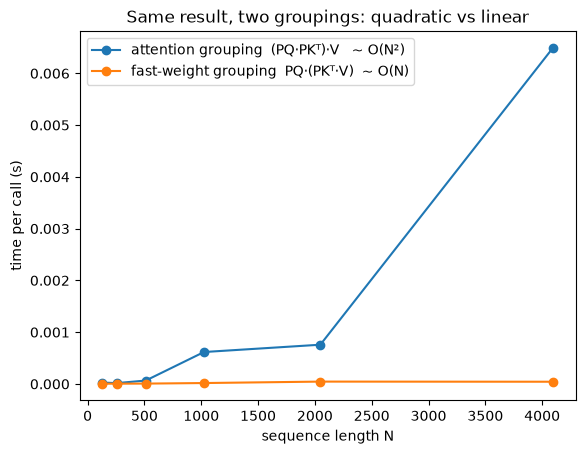

at N=4096: attention grouping 152x slower than fast-weight grouping


In [ ]:
def time_grouping(N, d=32, m=32, reps=5):
    Q, K, V = torch.randn(N, d), torch.randn(N, d), torch.randn(N, m)
    PQ, PK = phi(Q), phi(K)
    # quadratic: (PQ PK^T) V
    t0 = time.perf_counter()
    for _ in range(reps):
        _ = (PQ @ PK.t()) @ V
    t_quad = (time.perf_counter() - t0) / reps
    # linear: PQ (PK^T V)
    t0 = time.perf_counter()
    for _ in range(reps):
        _ = PQ @ (PK.t() @ V)
    t_lin = (time.perf_counter() - t0) / reps
    return t_quad, t_lin


Ns = [128, 256, 512, 1024, 2048, 4096]
tq, tl = zip(*[time_grouping(n) for n in Ns])
plt.plot(Ns, tq, marker="o", label="attention grouping  (PQ·PKᵀ)·V   ~ O(N²)")
plt.plot(Ns, tl, marker="o", label="fast-weight grouping  PQ·(PKᵀ·V)  ~ O(N)")
plt.xlabel("sequence length N")
plt.ylabel("time per call (s)")
plt.title("Same result, two groupings: quadratic vs linear")
plt.legend()
plt.show()
print(f"at N={Ns[-1]}: attention grouping {tq[-1] / tl[-1]:.0f}x slower than fast-weight grouping")

::: {.callout-note collapse="true"}
## Q: The parallel ↔ recurrent duality: which form trains, which infers, and why do they give the same function?

Both forms compute the *same* causal sum $\mathbf{o}_t\propto\sum_{j\le t}\big(\phi(\mathbf{q}_t)^\top\phi(\mathbf{k}_j)\big)\mathbf{v}_j$ — they just **schedule the arithmetic differently**.

- **Parallel form — for training.** Build the masked score matrix in one shot: $\mathbf{O}=\mathrm{tril}(\Phi_Q\Phi_K^\top)\,V$. Every position is computed at once, so it saturates a GPU — but it materializes the $N\times N$ scores, hence $O(N^2)$ compute/memory. You use it to **train** because there's no sequential dependency to wait on (and autograd flows through one big matmul). This is §4's `linear_attn_parallel_causal`.
- **Recurrent form — for inference.** Carry the running state $\mathbf{S}_t=\mathbf{S}_{t-1}+\mathbf{v}_t\phi(\mathbf{k}_t)^\top$ and read $\mathbf{o}_t\propto\mathbf{S}_t\phi(\mathbf{q}_t)$, one token at a time: $O(1)$ memory and time *per token*, $O(N)$ total, **no growing KV cache**. You use it to **decode**. This is §4's `linear_attn_recurrent` — M2's `FWPLayer` loop.

**Why identical:** it's just associativity + distributivity, reassociated. Grouping $(\Phi_Q\Phi_K^\top)V$ (scores first) versus accumulating $\sum_{j\le t}\mathbf{v}_j\phi(\mathbf{k}_j)^\top$ then reading (state first) are the same products summed in a different order. The causal mask "$j\le t$" is enforced two ways that agree: the `tril` zeroes future scores in the parallel form, while the recurrence has *only seen* tokens up to $t$ when it emits $\mathbf{o}_t$. §4's cell checked it: `O_rec == O_par` → `allclose True`.

**The deeper reason it's even *possible*:** the additive recurrence has state-Jacobian $\partial\mathbf{S}_t/\partial\mathbf{S}_{t-1}=I$ — linear and identity. That's what lets the unroll be reorganized into a single parallel matmul with no vanishing/exploding gradients, unlike a *nonlinear* RNN whose Jacobian product blows up or decays.

Katharopoulos et al. noticed this duality for one architecture; [Dao & Gu (2024)](https://arxiv.org/abs/2405.21060) made it the organizing principle. Their *structured state space duality* (SSD) connects state-space models and attention variants through decompositions of structured semiseparable matrices, so the recurrent ⇔ masked-matmul equivalence stops being a fact about linear attention and becomes a fact about a whole class — which is what let them design Mamba-2's core layer around the fast schedule. So: **train in parallel like a Transformer, run as an $O(1)$-memory RNN at inference — same weights, same function.**
:::

## 6. The feature map $\phi$ — what it buys and what it costs

Two jobs for $\phi$, both already visible in M1/M2:

1. **Non-negativity for the normalizer.** The denominator $\mathbf{z}_t^\top\phi(\mathbf{q}_t)$ must stay positive to act like a softmax-style average; $\phi=\mathrm{elu}+1>0$ guarantees it. This is Katharopoulos et al.'s choice (§3.2.1) — they take `elu` over `relu` precisely so the gradient does not die for negative inputs. (Many modern variants drop the denominator entirely and instead normalize $\mathbf{k},\mathbf{q}$ — exactly what M2's `FWPLayer` did with `F.normalize`.)
2. **Capacity.** From M2's capacity law, the memory resolves about as many associations as the **key dimension** — really the *effective rank* of the key set. Mapping keys through $\phi:\mathbb{R}^d\!\to\!\mathbb{R}^p$ with $p>d$ raises that dimension and spreads correlated keys apart, buying capacity back. **DPFP** (deterministic parameter-free projection) is one such map — FWP's own contribution ([Schlag et al., 2021](https://arxiv.org/abs/2102.11174), §5.4), combinatorial ReLU features that widen the key space without adding a single learned parameter, proposed there against the capacity problem that Katharopoulos's $\mathrm{elu}+1$ leaves open.

The cost is the catch: linear attention's fixed $p\times m$ state is **lossy** where softmax is exact. Superposing many outer products in one matrix causes interference, so exact copy/recall degrades — the same crosstalk wall from M1, now as the defining limitation of the whole family. The cell shows the gap: point the last query straight at one stored key and compare what softmax (§1) vs linear attention (§4) retrieve.

In [6]:
# A copy/recall probe: token 5 carries a distinctive key; the last query asks for its value.
torch.manual_seed(1)
Nq, dd = 40, 16
Kp = torch.randn(Nq, dd)
Vp = torch.randn(Nq, dd)
Qp = torch.randn(Nq, dd)
target = 5
Qp[-1] = Kp[target] * 4.0                       # last query points straight at key 5

O_soft, _ = softmax_attention(Qp, Kp, Vp, causal=True)
O_lin = linear_attn_recurrent(Qp, Kp, Vp)

err_soft = (O_soft[-1] - Vp[target]).norm() / Vp[target].norm()
err_lin  = (O_lin[-1]  - Vp[target]).norm() / Vp[target].norm()
print(f"recall error at the targeted query:  softmax {err_soft:.3f}   linear {err_lin:.3f}")
print("softmax isolates the target far more sharply; linear attention superposes -> lossy recall.")
print("That loss is the price of O(1) memory, and what M4's delta rule attacks.")

recall error at the targeted query:  softmax 0.139   linear 0.957
softmax isolates the target far more sharply; linear attention superposes -> lossy recall.
That loss is the price of O(1) memory, and what M4's delta rule attacks.


In [12]:
# A copy/recall probe with larger dimension: token 5 carries a distinctive key; the last query asks for its value.
torch.manual_seed(1)
Nq, dd = 40, 64
Kp = torch.randn(Nq, dd)
Vp = torch.randn(Nq, dd)
Qp = torch.randn(Nq, dd)
target = 5
Qp[-1] = Kp[target] * 4.0                       # last query points straight at key 5

O_soft, _ = softmax_attention(Qp, Kp, Vp, causal=True)
O_lin = linear_attn_recurrent(Qp, Kp, Vp)

err_soft = (O_soft[-1] - Vp[target]).norm() / Vp[target].norm()
err_lin  = (O_lin[-1]  - Vp[target]).norm() / Vp[target].norm()
print(f"recall error at the targeted query:  softmax {err_soft:.3f}   linear {err_lin:.3f}")
print("softmax isolates the target far more sharply; linear attention superposes -> lossy recall.")
print("That loss is the price of O(1) memory, and what M4's delta rule attacks.")

recall error at the targeted query:  softmax 0.000   linear 0.981
softmax isolates the target far more sharply; linear attention superposes -> lossy recall.
That loss is the price of O(1) memory, and what M4's delta rule attacks.


::: {.callout-note collapse="true"}
## Q: What does linearizing cost, and what do the two jobs of $\phi$ buy back?

**The cost: lossy superposition.** Softmax keeps *every* token and can isolate any one of them, so recall is exact — but it pays $O(N^2)$ and an unbounded KV cache. Linear attention throws all of that away into **one fixed $p\times m$ matrix** $\mathbf{S}_t=\sum_{j\le t}\mathbf{v}_j\phi(\mathbf{k}_j)^\top$. Every association is *superposed* in the same matrix, so once you store more than about $p$ near-orthogonal keys (really the **effective rank** of the key set, M2's capacity law), new writes interfere with old ones and a query returns a contaminated blend instead of the value you wanted. The probe above is exactly this trade: softmax recall error $0.139$ (and $\to 0.000$ at $\texttt{dd=64}$) vs linear $0.957$. So the price of $O(1)$ memory and $O(N)$ time is **exact recall** — you can no longer pull out a single stored token cleanly. (M4's delta rule softens this by *editing* instead of piling on, but the fixed-size lossiness is inherent to the family.)

**What $\phi$ buys (the two jobs above):**

1. **Non-negativity for the normalizer.** The denominator $\mathbf{z}_t^\top\phi(\mathbf{q}_t)$ must stay positive for $\mathbf{o}_t$ to behave like a weighted *average*; $\phi=\mathrm{elu}+1>0$ guarantees it. (Many modern variants drop the denominator entirely and instead $L_2$-normalize $\mathbf{k},\mathbf{q}$ — exactly what M2's `FWPLayer` did with `F.normalize`.)
2. **Capacity / effective rank.** Mapping keys through $\phi:\mathbb{R}^d\to\mathbb{R}^p$ with $p>d$ (e.g. DPFP's combinatorial ReLU features) raises the nominal key dimension **and** spreads correlated keys into more orthogonal directions — recovering effective rank, so more associations fit before they interfere (M1's crosstalk wall, M2's capacity law).

Neither job removes the lossiness; they push the wall further out. The exactness gap between softmax and *any* finite $\phi$ is the same point as Q1: a finite feature map is a finite-rank approximation of the infinite-dimensional $\exp$ kernel.
:::

## Code walkthrough — linear attention in real code

The recurrence we wrote by hand is the whole of a production linear-attention layer. From [`linear_attention.py`](https://github.com/idiap/fast-transformers/blob/master/fast_transformers/attention/linear_attention.py) in [idiap/fast-transformers](https://github.com/idiap/fast-transformers), the Linear Transformers paper's own library — non-causal:

```python
Q, K = feature_map(Q), feature_map(K)          # phi = elu(x)+1
KV = torch.einsum("nshd,nshm->nhmd", K, V)     # S = sum_j phi(k_j) v_j^T   (the fast weights)
Z  = 1 / torch.einsum("nlhd,nhd->nlh", Q, K.sum(dim=1))   # normalizer 1 / (phi(q)·z)
V_out = torch.einsum("nlhd,nhmd,nlh->nlhm", Q, KV, Z)     # o = S phi(q) / (...)
```

[`causal_linear_attention.py`](https://github.com/idiap/fast-transformers/blob/master/fast_transformers/attention/causal_linear_attention.py) swaps the one-shot `KV` for the **running** $\mathbf{S}_t$ we built in §4 (a custom CUDA scan), giving the $O(N)$ inference path.

- [`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) → `SelfModifyingLayer` is the same loop in M2's notation: `memory = a_t * memory + update`; `update` is the outer product $\mathbf{v}_t\phi(\mathbf{k}_t)^\top$.
- [`linearAttention.py`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/linearAttention.py) — the FWP paper's own code — is this exact recurrence, written from the fast-weights side; the clearest single file showing "linear attention" and "fast weights" are one loop.

## Exit check

Ready for M4 when you can:

1. Rebuild softmax attention from query/key/value, and say why softmax forbids the collapse but $\phi(\mathbf{q})^\top\phi(\mathbf{k})$ allows it — and what object the collapse produces.
2. Write the boxed recurrence $\mathbf{S}_t=\mathbf{S}_{t-1}+\mathbf{v}_t\phi(\mathbf{k}_t)^\top$ from memory and point to where it is M2's fast-weight write.
3. Explain the parallel ↔ recurrent duality: which form trains, which infers, and why both give the same function.
4. State the cost of going linear (lossy superposition / recall) and name the two things $\phi$ buys.

**Next → M4, the delta rule / DeltaNet.** Linear attention only ever *adds* to $\mathbf{S}$ — §6's lossy recall is the symptom. M4 replaces the additive write with an **error-correcting** one: before writing, read what's already stored for this key and write only the *difference*. That single change turns the pile-on memory into one that can *edit* associations — the first real fix to the crosstalk wall we've now hit three times.